In [34]:
################################################################################
##### Pacotes
################################################################################
# Manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem estatística
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Diagnóstico de resíduos e influência
from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.stats.api as sms
from scipy import stats

In [ ]:
################################################################################
##### Regressão Linear Simples
################################################################################

# Configurações gerais de plot
sns.set_theme(style="whitegrid")


################################################################################
##### Importação / Entrada dos dados
################################################################################
# Dataset Boston do pacote MASS (R)
boston = sm.datasets.get_rdataset("Boston", "MASS").data

# Inspeção rápida da estrutura (equivalente a psych::headTail() e summary())
print(boston.head())
print(boston.tail())
print(boston.info())
print(boston.describe())


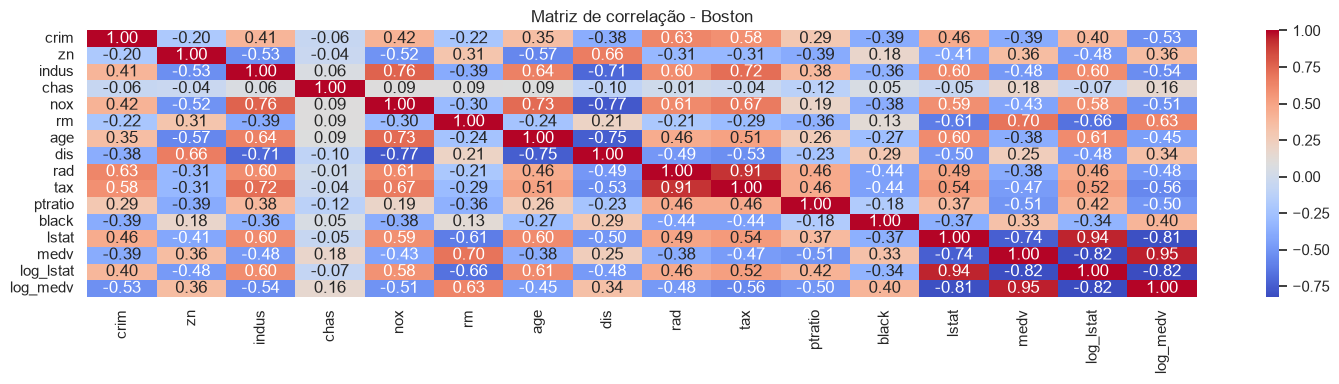

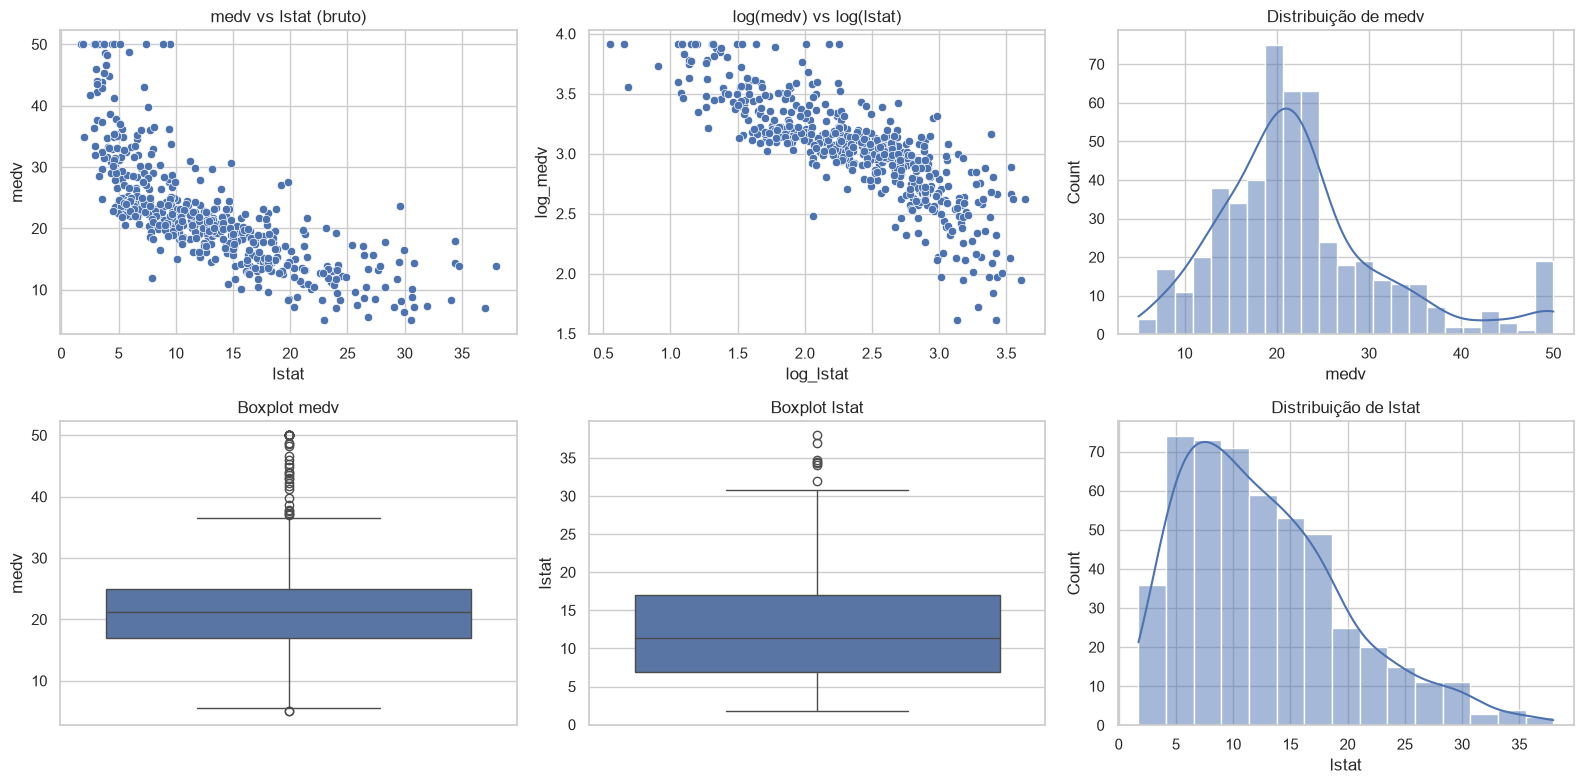

               medv     lstat  log_lstat
medv       1.000000 -0.737663  -0.815442
lstat     -0.737663  1.000000   0.944031
log_lstat -0.815442  0.944031   1.000000


In [38]:


################################################################################
##### Preparação / Recodificação dos dados
################################################################################
# Transformações de variáveis explicativas (log, padronização/escala)
boston["log_lstat"] = np.log(boston["lstat"])
boston["log_medv"] = np.log(boston["medv"])

################################################################################
##### Análise descritiva / Visualização inicial
################################################################################
plt.figure(figsize=(15, 4))
sns.heatmap(boston.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação - Boston")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.scatterplot(data=boston, x="lstat", y="medv", ax=axes[0, 0])
axes[0, 0].set_title("medv vs lstat (bruto)")

sns.scatterplot(data=boston, x="log_lstat", y="log_medv", ax=axes[0, 1])
axes[0, 1].set_title("log(medv) vs log(lstat)")

sns.histplot(data=boston, x="medv", kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Distribuição de medv")

sns.boxplot(data=boston, y="medv", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot medv")

sns.boxplot(data=boston, y="lstat", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot lstat")

sns.histplot(data=boston, x="lstat", kde=True, ax=axes[1, 2])
axes[1, 2].set_title("Distribuição de lstat")

plt.tight_layout()
plt.show()

print(boston[["medv", "lstat", "log_lstat"]].corr())



In [39]:

################################################################################
##### Ajuste do Modelo
################################################################################
# Regressão linear simples: y = beta0 + beta1 * x + erro
# Usando a interface de fórmulas (semelhante ao lm() do R)

modelo = smf.ols("log_medv ~ log_lstat", data=boston).fit()
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:               log_medv   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     1058.
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          7.32e-126
Time:                        00:43:29   Log-Likelihood:                 21.325
No. Observations:                 506   AIC:                            -38.65
Df Residuals:                     504   BIC:                            -30.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3618      0.042    103.603      0.0

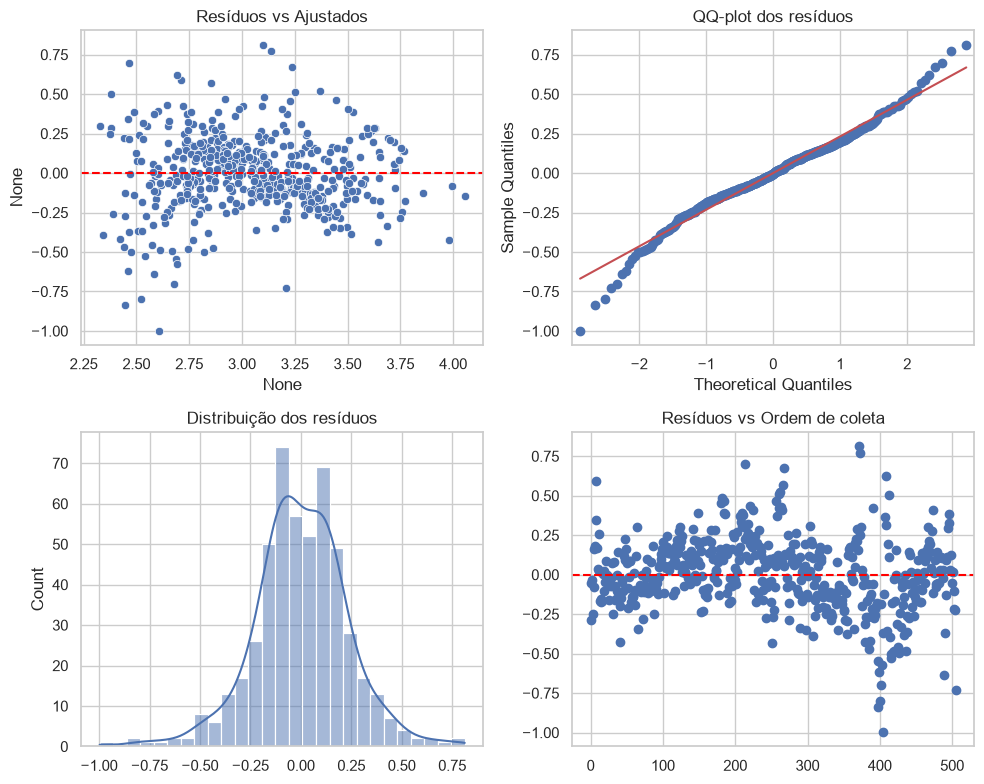

Shapiro-Wilk (normalidade): ShapiroResult(statistic=np.float64(0.9815057762506313), pvalue=np.float64(4.880868166881455e-06))
Breusch-Pagan (homocedasticidade): (np.float64(16.31596761443809), np.float64(5.36103049747937e-05), np.float64(16.79296675780125), np.float64(4.857497666276674e-05))
Durbin-Watson (independência): 0.8548961000697274


In [40]:
################################################################################
##### Diagnóstico / Análise de Resíduos
################################################################################
# Pressupostos: linearidade, homocedasticidade, normalidade e independência

residuos = modelo.resid
ajustados = modelo.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Resíduos vs Ajustados (linearidade/homocedasticidade)
sns.scatterplot(x=ajustados, y=residuos, ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Resíduos vs Ajustados")

# QQ-plot (normalidade)
sm.qqplot(residuos, line="s", ax=axes[0, 1])
axes[0, 1].set_title("QQ-plot dos resíduos")

# Histograma dos resíduos
sns.histplot(residuos, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição dos resíduos")

# Resíduos padronizados vs ordem (independência)
axes[1, 1].plot(residuos, marker="o", linestyle="")
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Resíduos vs Ordem de coleta")

plt.tight_layout()
plt.show()

# Testes formais de pressupostos
print("Shapiro-Wilk (normalidade):", stats.shapiro(residuos))
print("Breusch-Pagan (homocedasticidade):", sms.het_breuschpagan(residuos, modelo.model.exog))
print("Durbin-Watson (independência):", sm.stats.stattools.durbin_watson(residuos))

      cooks_d  leverage  resid_student
398  0.052888  0.008019      -3.661481
405  0.048149  0.005175      -4.379687
400  0.039374  0.006581      -3.485699
214  0.035045  0.007628       3.044430
40   0.030760  0.017600      -1.857562


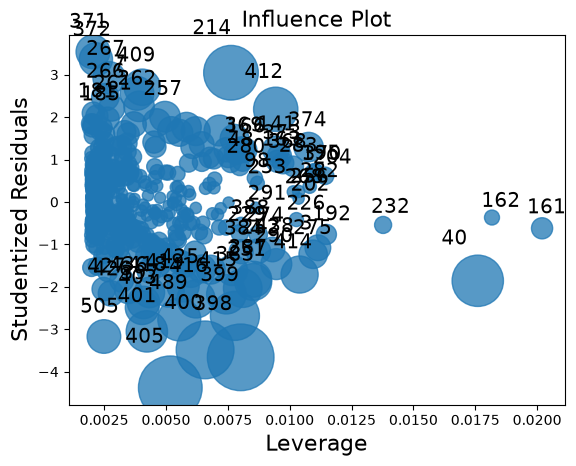

In [ ]:

################################################################################
##### Diagnóstico de Observações Influentes e Análise de Sensibilidade
################################################################################
influencia = OLSInfluence(modelo)

# Distância de Cook, leverage e resíduos studentizados
diagnostico = pd.DataFrame({
 "cooks_d": influencia.cooks_distance[0],
    "leverage": influencia.hat_matrix_diag,
    "resid_student": influencia.resid_studentized_external
 })
print(diagnostico.sort_values("cooks_d", ascending=False).head())

# Gráfico de influência
sm.graphics.influence_plot(modelo)
plt.show()


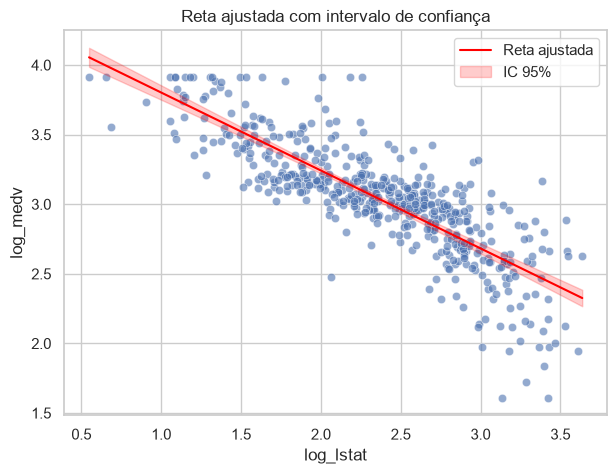

       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  2.884430  0.013007       2.858937       2.909922      2.428134   
1  2.457769  0.025734       2.407332       2.508206      1.999402   

   obs_ci_upper  
0      3.340726  
1      2.916136  


In [41]:


################################################################################
##### Efeitos Ajustados, Representação Gráfica e Predições
################################################################################
# Reta ajustada com intervalo de confiança
modelo_log_log_robusto = smf.ols("log_medv ~ log_lstat", data=boston).fit(cov_type="HC3")

lstat_novo = pd.DataFrame({"log_lstat": np.linspace(boston["log_lstat"].min(), boston["log_lstat"].max(), 100)})
predicoes = modelo_log_log_robusto.get_prediction(lstat_novo).summary_frame(alpha=0.05)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=boston, x="log_lstat", y="log_medv", alpha=0.6)
plt.plot(lstat_novo["log_lstat"], predicoes["mean"], color="red", label="Reta ajustada")
plt.fill_between(lstat_novo["log_lstat"], predicoes["mean_ci_lower"], predicoes["mean_ci_upper"],color="red", alpha=0.2, label="IC 95%")
plt.legend()
plt.xlabel("log_lstat")
plt.ylabel("log_medv")
plt.title("Reta ajustada com intervalo de confiança")
plt.show()

# Predições pontuais e intervalos (confiança e predição) para novos valores
novos_dados = pd.DataFrame({"log_lstat": [np.log(14), np.log(30)]})
pred_media = modelo_log_log_robusto.get_prediction(novos_dados).summary_frame(alpha=0.05)  # IC da média
pred_obs = modelo_log_log_robusto.get_prediction(novos_dados).summary_frame(alpha=0.05)    # IC de predição (obs_labels=True)
print(pred_media)